# Cylindrical Magnet Array Optimization - Example Usage

This notebook demonstrates using the `cylindrical_opt` package for GPU-accelerated permanent magnet array optimization.

**This is an example usage notebook.** Parameters shown are for demonstration - adjust for your specific design requirements.

**Package Features:**
- 3-phase hybrid perturbation (exploration → transition → exploitation)
- S-curve temperature scaling
- Ben-Ameur auto-calibration
- REFLECTION bounds handling
- Bolt hole avoidance constraints
- Octant symmetry (8× reflection)


## 1. Imports

In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from datetime import datetime
from pytictoc import TicToc
t = TicToc()

# Import the cylindrical optimization package
from cylindrical_opt import (
    field_calculator,
    sampling,
    generator,
    perturbation,
    constraints,
    cost,
    optimizer,
    calibration,
    visualization
)

# Alias for compatibility with original notebook
GRFC = field_calculator

print("All imports successful!")

All imports successful!


In [2]:
# ======================================================================
# RANDOM SEED FOR REPRODUCIBILITY
# ======================================================================
RANDOM_SEED = 42  # Set to None for non-reproducible runs

if RANDOM_SEED is not None:
    np.random.seed(RANDOM_SEED)
    cp.random.seed(RANDOM_SEED)
    print(f"✓ Random seed set to {RANDOM_SEED} for reproducibility")
else:
    print("⚠ No random seed - results will vary between runs")

✓ Random seed set to 42 for reproducibility


## 2. Load Precomputed Field Data

In [3]:
# Load precomputed magnetic field lookup table
# NOTE: You can generate your own precomputed field using:
#       precompute/Generate_Precomputed_Field_Batched_analytical.ipynb
#       Adjust grid size, magnet parameters (Br, demagnetization) as needed.

B = np.load('Precalc_field_450mm_grid_1mm_step_Br1.48_demag0.9836_20260701_220818.npz')
Precalc_Bxyz_value = B['Bxyzvalue'].astype(np.float32)
Ref_grid = B['Ref_grid']
step_size = float(B['step_size'])
GRFC.load_field(Precalc_Bxyz_value, Ref_grid, step_size)

✓ Field loaded to GPU: (91125000, 3) (1.09 GB)
  Grid: 450x450x450, step=1.0mm


## 3. Define Design Parameters

In [4]:
inmm = 1e-3
halbach_magnet_size = 6.35 * inmm  # 6.35mm cube magnets

# Geometry parameters (user-defined)
n_magnets_octant = 45    # Magnets in first octant (reflected to 8 octants)
n_magnets = n_magnets_octant * 8  # Total magnets in full configuration
z_min = -0.0975          # Minimum z (-97.5mm)
z_max = 0.0975           # Maximum z (+97.5mm)
r_min = 0.07             # Inner radius (70mm)
r_max = 0.085            # Outer radius (85mm)
clearance = 0.0          # Additional clearance beyond minimum spacing

# DSV parameters
n_sample_points = 1500   # DSV sample points
sphere_radius = r_min * 0.5  # DSV radius (50% of inner radius)

# Cost function weights
weights = {
    'field_strength': 50000,       # Weight for maximizing field
    'uniformity': 50000 * 10,      # Weight for field homogeneity (500,000)
    'z_barrier': 5.0,              # Soft barrier at z bounds
    'overlap_barrier': 5.0,        # Soft barrier for magnet overlap
    'radius_barrier': 5.0          # Soft barrier at radial bounds
}

# Perturbation step divisors
step_divisors = {
    'z': 40,       # Z-axis step divisions
    'r': 55,       # Radial step divisions
    'theta': 55,   # Angular step divisions
    'phi': 50      # Orientation step divisions
}

# SA parameters
n_iterations = None      # Set by calibration
initial_temp = 50        # Starting temperature
cooling_rate = 0.99995   # Temperature decay rate
display_interval = 1000  # Print progress every N iterations

print(f"Design: r_min={r_min*1000:.1f}mm, r_max={r_max*1000:.1f}mm")
print(f"z range: [{z_min*1000:.1f}, {z_max*1000:.1f}] mm")
print(f"Magnets: {n_magnets_octant} per octant -> {n_magnets} total")
print(f"Weights: field={weights['field_strength']}, uniformity={weights['uniformity']}")


Design: r_min=70.0mm, r_max=85.0mm
z range: [-97.5, 97.5] mm
Magnets: 45 per octant -> 360 total
Weights: field=50000, uniformity=500000


## 4. Generate DSV Sample Points

In [5]:
# Generate sample points (using module)
sample_points_small = sampling._generate_sample_points_small_dsv(
    n_sample_points, sphere_radius,
    z_min + halbach_magnet_size, z_max - halbach_magnet_size
)

print(f"Generated {len(sample_points_small)} DSV sample points")

Generated 1500 DSV sample points


## 5. Generate Initial Configuration

In [ ]:
# ======================================================================
# GENERATE INITIAL CONFIGURATION
# ======================================================================
# For a FIRST RUN: Generate random initial configuration
first_octant = generator.generate_first_octant(
    n_magnets=n_magnets_octant,
    z_max=z_max,
    r_min=r_min,
    r_max=r_max,
    magnet_size=halbach_magnet_size
)

# ======================================================================
# FOR A SECOND RUN: Load previous result and continue optimizing
# Uncomment below and comment out the generate_first_octant block above:
# ======================================================================
# prev = np.load('cylindrical_design_YYYYMMDD_HHMMSS.npz')
# first_octant = cp.asarray(prev['octant_config'])
# print(f"Loaded previous result: {len(first_octant)} magnets")

# Reflect to all 8 octants
full_config = generator.reflect_to_octants(first_octant)

print(f"First octant: {len(first_octant)} magnets")
print(f"Full config: {len(full_config)} magnets")

# Check z range
z_magnets = first_octant[:, 0]
print(f"Magnet z range: [{float(z_magnets.min())*1000:.2f}mm, {float(z_magnets.max())*1000:.2f}mm]")

In [7]:
# Calculate initial field for comparison
B_init, B_mag_init = GRFC.calc_field(full_config, sample_points_small)
initial_avg_field = float(cp.mean(B_mag_init))
initial_std_field = float(cp.std(B_mag_init))
initial_homogeneity = initial_std_field / initial_avg_field * 100

print("="*50)
print("INITIAL CONFIGURATION")
print("="*50)
print(f"Field: {initial_avg_field:.2f} mT")
print(f"Homogeneity: {initial_homogeneity:.2f}%")
print("="*50)

INITIAL CONFIGURATION
Field: 5.20 mT
Homogeneity: 5.04%


## 6. Visualize Initial Configuration

In [8]:
# Interactive 3D plot
visualization.Plot_positions_plotly(first_octant, sample_points_small)

## 7. Auto-Calibrate SA Parameters

In [9]:
# Run SA calibration (EXACT from original notebook)
# Need to set n_iterations first for calibration
if n_iterations is None:
    n_iterations = 100000

T0, Tf, alpha, diag = calibration.calibrate_sa_cylindrical(
    initial_config=first_octant,
    z_min=z_min,
    z_max=z_max,
    r_min=r_min,
    r_max=r_max,
    magnet_size=halbach_magnet_size,
    sample_points=sample_points_small,
    weights=weights,
    step_divisors=step_divisors,
    Precalc_Bxyz_value=Precalc_Bxyz_value,
    Ref_grid=Ref_grid,
    step_size=step_size,
    cooling_rate=cooling_rate,
    n_iterations=100000,
    n_samples=200,
    chi_0=0.9,
    chi_f=0.01,
    moves_per_level=1,
    hot_temp=1e4,
    cold_ratio=0.01,
)

# Apply calibration
initial_temp = T0
cooling_rate = alpha
print(f"\n✓ Applied: initial_temp = {initial_temp:,.0f}, cooling_rate = {cooling_rate:.8f}")

# Auto-calculate iterations (from original)
T_final_target = 1
n_iterations_override = 100000

if n_iterations_override is not None:
    n_iterations = n_iterations_override
    cooling_rate = (T_final_target / T0) ** (1 / n_iterations)
    print(f"\n>>> OVERRIDE: Using {n_iterations:,} iterations")
    print(f">>> Adjusted cooling_rate = {cooling_rate:.10f}")

T_final_actual = T0 * (cooling_rate ** n_iterations)
print(f"\n  T0 = {T0:,.0f}")
print(f"  T_final_actual = {T_final_actual:.2f}")


SA RIGOROUS CALIBRATION (Cylindrical Octant)

Base cost: -223,157.63

Step 2: Random-walk sampling 200 moves (hot)...
  72 uphill moves from 201 configs
  ΔE  min 0.371   median 221   mean 1.11e+03   max 2e+04

Step 2b: Sampling at cold step size (ratio 0.01)...
  49 uphill moves,  median ΔE 232

Step 3: Solving χ(T₀)=0.9, χ(T_f)=0.01 ...
  T₀  = 6,201   (verify χ = 90.0%)
  T_f = 19.3   (verify χ = 1.00%)

Step 4: cooling
  n_iterations 100,000  /  moves_per_level 1  →  K = 100,000 cooling events
  α = 0.99994228

initial_temp = 6,201.18
cooling_rate = 0.99994228

✓ Applied: initial_temp = 6,201, cooling_rate = 0.99994228

>>> OVERRIDE: Using 100,000 iterations
>>> Adjusted cooling_rate = 0.9999126789

  T0 = 6,201
  T_final_actual = 1.00


## 8. Run Optimization

In [10]:
# Set iterations if not calibrated
if n_iterations is None:
    n_iterations = 30000

# Run simulated annealing optimization
best_octant, best_cost, history = optimizer.simulated_annealing_optimized(
    initial_config=first_octant,
    z_min=z_min,
    z_max=z_max,
    r_min=r_min,
    r_max=r_max,
    magnet_size=halbach_magnet_size,
    sample_points=sample_points_small,
    weights=weights,
    Precalc_Bxyz_value=Precalc_Bxyz_value,
    Ref_grid=Ref_grid,
    step_size=step_size,
    step_divisors=step_divisors,
    initial_temp=initial_temp,
    cooling_rate=cooling_rate,
    n_iterations=n_iterations,
    display_interval=display_interval, verbose=True, debug_cost=True
)

# Reflect to full config
best_full = generator.reflect_to_octants(best_octant)

print("\nOptimization complete!")
print(f"Best cost: {best_cost:.2f}")

Starting simulated annealing optimization...
Iteration 1000/100000, Temperature: 5682.631702, Cost: -299175.067765
Improvements found: 66, Invalid configurations: 0
  Best solution metrics:
  → Avg field strength: 7.00 mT
  → Field uniformity (RMS dev): 0.21 mT
  → Weighted components - Field: -349942.72, Uniformity: 104081.67
Iteration 2000/100000, Temperature: 5207.445906, Cost: -428264.084005
Improvements found: 124, Invalid configurations: 0
  Best solution metrics:
  → Avg field strength: 9.41 mT
  → Field uniformity (RMS dev): 0.27 mT
  → Weighted components - Field: -470359.31, Uniformity: 133186.98
Iteration 3000/100000, Temperature: 4771.995493, Cost: -463594.666206
Improvements found: 171, Invalid configurations: 0
  Best solution metrics:
  → Avg field strength: 9.89 mT
  → Field uniformity (RMS dev): 0.22 mT
  → Weighted components - Field: -494349.34, Uniformity: 112404.07
Iteration 4000/100000, Temperature: 4372.957759, Cost: -488947.375657
Improvements found: 215, Invali

## 9. Analyze Results

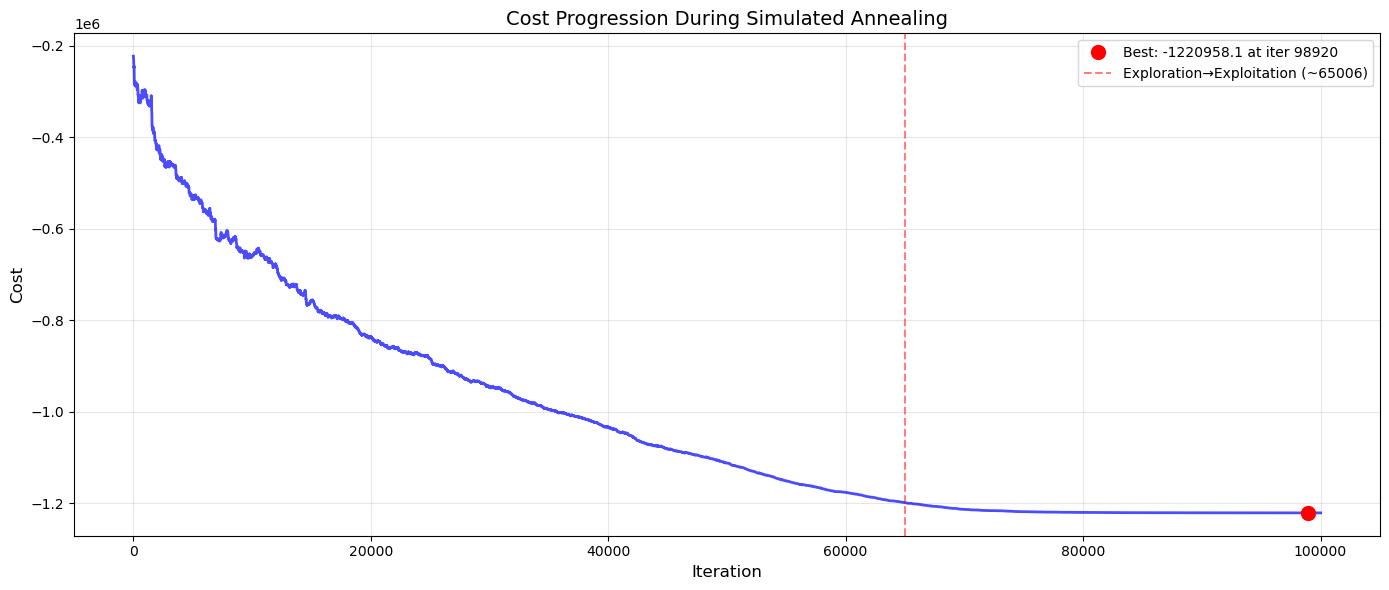

Cost progression summary:
  Initial cost: -223157.6
  Final cost: -1220957.6
  Best cost: -1220958.1 (at iteration 98920)
  Total improvement: -997800.0
  Improvement rate: -99.8 per checkpoint


In [11]:
# Plot cost progression
visualization.plot_cost_progression(history)

In [12]:
# Evaluate final performance
B_field, B_mag = GRFC.calc_field(best_full, sample_points_small)

avg_field = float(cp.mean(B_mag))
std_field = float(cp.std(B_mag))
homogeneity_pct = (std_field / avg_field) * 100 if avg_field > 0 else 0
homogeneity_ppm = homogeneity_pct * 10000

print("="*60)
print("FINAL PERFORMANCE SUMMARY")
print("="*60)
print(f"Average field:    {avg_field:.2f} mT")
print(f"Field std:        {std_field:.4f} mT")
print(f"Homogeneity:      {homogeneity_pct:.2f}% ({homogeneity_ppm:.0f} ppm)")
print(f"Total magnets:    {len(best_full)}")
print(f"Best cost:        {best_cost:.2f}")
print("="*60)

FINAL PERFORMANCE SUMMARY
Average field:    26.01 mT
Field std:        0.3779 mT
Homogeneity:      1.45% (14530 ppm)
Total magnets:    360
Best cost:        -1220958.06


## 10. Visualize Final Configuration

In [13]:
# Interactive 3D plot of optimized configuration
visualization.Plot_positions_plotly(cp.asarray(best_full), sample_points_small)

## 11. Save Results

In [14]:
# Save comprehensive results
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"cylindrical_design_{timestamp}.npz"

# Convert to numpy for saving
best_octant_cpu = cp.asnumpy(best_octant) if isinstance(best_octant, cp.ndarray) else best_octant
best_full_cpu = cp.asnumpy(best_full) if isinstance(best_full, cp.ndarray) else best_full

np.savez(
    filename,
    octant_config=best_octant_cpu,
    full_config=best_full_cpu,
    cost=float(best_cost),
    r_min=r_min,
    r_max=r_max,
    z_min=z_min,
    z_max=z_max,
    n_iterations=n_iterations,
    field_mT=avg_field,
    homogeneity_ppm=homogeneity_ppm
)

print(f"\nSaved to: {filename}")
print(f"Field: {avg_field:.2f} mT")
print(f"Homogeneity: {homogeneity_ppm:.0f} ppm")


Saved to: cylindrical_design_20261006_130944.npz
Field: 26.01 mT
Homogeneity: 14530 ppm


## 12. Visualization & Comparison

In [15]:
# 3D Visualization of Optimized Design
import sys
sys.path.insert(0, '..')
import visualize_configuration as VS
import field_validation as fv

view = VS.rad_halbach_Design_rad(halbach_magnet_size, cp.asnumpy(best_full))
view.show()

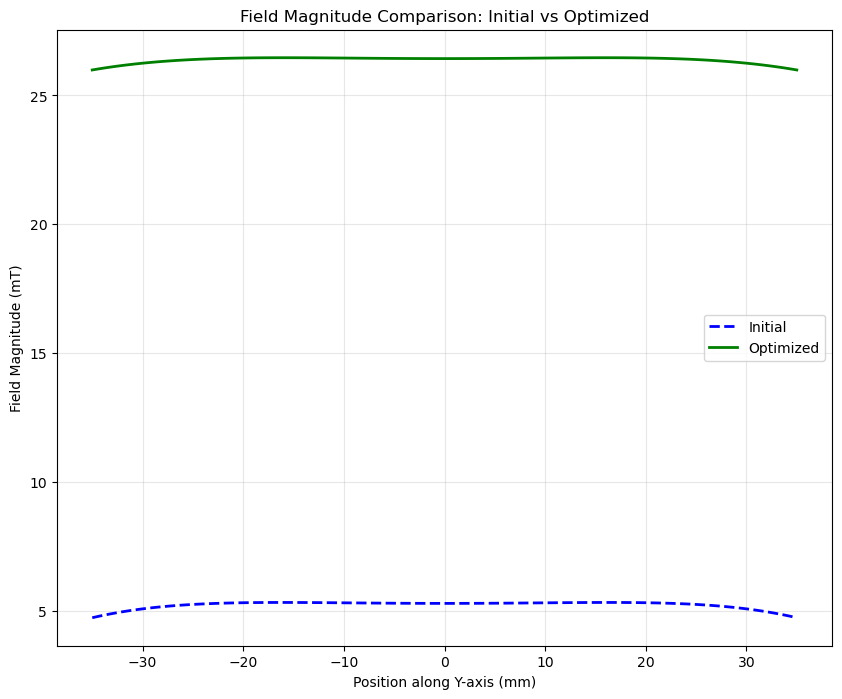

In [16]:
# Overlay: Initial vs Optimized Field Magnitude (Magpylib Validation)
# Define axis range (adjust as needed)
axis_range = sphere_radius  # Use DSV radius, or set custom e.g. 0.035

# Create magpylib views
initial_full = generator.reflect_to_octants(first_octant)
initial_view = VS.rad_halbach_Design_rad(halbach_magnet_size, cp.asnumpy(initial_full))
optimized_view = VS.rad_halbach_Design_rad(halbach_magnet_size, cp.asnumpy(best_full))

# Use module function for overlay comparison
fv.overlay_comparison(initial_view, optimized_view, axis_range=axis_range,
                      initial_label="Initial", optimized_label="Optimized");

## 13. Cleanup GPU Memory

In [17]:
# Clean up GPU memory
cp.get_default_memory_pool().free_all_blocks()
print("GPU memory cleared")

GPU memory cleared
